In [2]:
import os 
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import CGConv, global_mean_pool, global_add_pool

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# MPS has incomplete PyG support — use CPU for GNN training
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

os.makedirs("../models", exist_ok=True)
os.makedirs("../figures",exist_ok=True)

/opt/homebrew/Caskroom/miniconda/base/envs/solid_electrolyte_gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps
PyTorch version: 2.11.0


In [3]:
df = pd.read_csv("../data/processed/solid_electrolyte_features.csv")
print(f"Dataframe loaded: {df.shape}")

with open("../data/raw/structures.json","r") as f:
    structures_dict = json.load(f)
print(f"Structures loaded: {len(structures_dict)}")

valid_ids = set(structures_dict.keys()) & set(df["material_id"].values)
df = df[df["material_id"].isin(valid_ids)].reset_index(drop=True)
print(f"Materials with both structures and features: {df.shape[0]}")

Dataframe loaded: (15362, 22)
Structures loaded: 15362
Materials with both structures and features: 15362


In [4]:
from pymatgen.core import Structure, Element

def get_node_features(site):
    el = site.specie
    try:
        atomic_radius = float(el.atomic_radius) if el.atomic_radius else 0.0
    except:
        atomic_radius = 0.0
    try:
        ionic_radius = float(list(el.ionic_radii.values())[0]) if el.ionic_radii else 0.0
    except:
        ionic_radius = 0.0
    try:
        row = float(el.row) if el.row else 0.0
    except:
        row = 0.0
    try:
        group = float(el.group) if el.group else 0.0
    except:
        group = 0.0

    return [
        float(el.Z),
        float(el.X) if el.X else 0.0,
        atomic_radius,
        ionic_radius,
        row,
        group,
        1.0 if str(el) in ["Li", "Na"] else 0.0,
    ]
NODE_FEATURE_DIM = 7
print(f"Node features dimension: {NODE_FEATURE_DIM}")

Node features dimension: 7


In [5]:
def structure_to_graph(material_id,band_gap,structures_dict,cutoff=6.0):
    """
    Convert a crystal structure to a PyG Data object.
    Nodes = atoms, Edges = bonds within cutoff radius.
    Edge features = [bond distance, periodic image flags].
    """ 
    try:
        struct = Structure.from_dict(structures_dict[material_id])
        # Node features
        node_facts = [get_node_features(site) for site in struct]
        x = torch.tensor(node_facts, dtype=torch.float)

        # Edge features
        all_neighbors = struct.get_all_neighbors(cutoff,include_index=True)
        edge_index = []
        edge_attr = []
        for i, neighbors in enumerate(all_neighbors):
            for neighbor in neighbors:
                j = neighbor[2]  # neighbor index
                dist = neighbor[1]
                edge_index.append([i,j])
                edge_attr.append([dist])
        if len(edge_index) == 0:
            return None  # No edges, skip this structure
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)
        y = torch.tensor([band_gap], dtype=torch.float)
        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    except Exception as e:
        return None

# Build graph dataset
print("Building crystal graphs...")
graph_list = []
skipped = 0

for _,row in df.iterrows():
    graph = structure_to_graph(row["material_id"], row["band_gap"], structures_dict)
    if graph is not None:
        graph_list.append(graph)
    else:
        skipped += 1
graph_list = graph_list[:3000]  # Limit to 3000 graphs for faster training
print(f"Total graphs: {len(graph_list)}, Skipped: {skipped}")
print(f"Skipped: {skipped}")
print(f"Example graph: {graph_list[0]}")

Building crystal graphs...
Total graphs: 3000, Skipped: 0
Skipped: 0
Example graph: Data(x=[10, 7], edge_index=[2, 90], edge_attr=[90, 1], y=[1])


In [6]:
from torch_geometric.loader import DataLoader

torch.manual_seed(42)
np.random.seed(42)

n = len(graph_list)
n_test = int(0.15*n)
n_val = int(0.15*n)
n_train = n-n_test-n_val

indices = np.random.permutation(n)
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train+n_val]
test_idx = indices[n_train+n_val:]

train_data = [graph_list[i] for i in train_idx]
val_data = [graph_list[i] for i in val_idx]
test_data = [graph_list[i] for i in test_idx]

train_loader = DataLoader(train_data,batch_size=64,shuffle=True)
val_loader = DataLoader(val_data,batch_size=64,shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Train:{len(train_data)}| Val:{len(val_data)}| Test: {len(test_data)}")

Train:2100| Val:450| Test: 450


In [7]:
class CrystalGNN(nn.Module):
    """
    CGCNN-style graph neural network for crystal property prediction.
    Uses CGConv layers (crystal graph convolution) from PyTorch Geometric.
    Readout: global mean pooling -> MLP -> scalar prediction.
    """

    def __init__(self,node_dim,edge_dim,hidden_dim=128,n_conv=4,dropout=0.1):
        super().__init__()

        #input projection
        self.input_proj = nn.Linear(node_dim,hidden_dim)

        # Crystal graph convolution layers
        self.conv_layers = nn.ModuleList([
            CGConv(hidden_dim,dim=edge_dim,aggr="mean",batch_norm=True)
            for _ in range(n_conv)
        ])

        self.dropout = nn.Dropout(dropout)

        # Readout MLP
        self.readout = nn.Sequential(
            nn.Linear(hidden_dim,64),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(64,32),
            nn.SiLU(),
            nn.Linear(32,1)
        )
    
    def forward(self,data):
        x, edge_index, edge_attr, batch = (
            data.x,data.edge_index,data.edge_attr,data.batch
        )
        x = F.silu(self.input_proj(x))
        for conv in self.conv_layers:
            x = conv(x,edge_index,edge_attr)
            x = F.silu(x)
            x = self.dropout(x)

        # Global pooling - aggregate atom embeddings to graph embedding
        x = global_mean_pool(x,batch)

        # Predict
        out = self.readout(x)
        return out.squeeze(-1)

model = CrystalGNN(
    node_dim =NODE_FEATURE_DIM,
    edge_dim = 1,
    hidden_dim=128,
    n_conv=4,
    dropout=0.1
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")
    

CrystalGNN(
  (input_proj): Linear(in_features=7, out_features=128, bias=True)
  (conv_layers): ModuleList(
    (0-3): 4 x CGConv(128, dim=1)
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (readout): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): SiLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): SiLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters: 276,609


In [8]:
optimizer = Adam(model.parameters(),lr=1e-3,weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer,mode="min",factor=0.5,patience=10)
criterion = nn.MSELoss()

def train_epoch(loader):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch)
        loss = criterion(pred,batch.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step()
        total_loss += loss.item()*batch.num_graphs
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(loader):
    model.eval()
    preds,targets=[],[]
    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)
        preds.extend(pred.cpu().numpy())
        targets.extend(batch.y.cpu().numpy())
    preds = np.array(preds)
    targets = np.array(targets)
    return {
        "mse": mean_squared_error(targets,preds),
        "mae":mean_absolute_error(targets,preds),
        "r2":r2_score(targets,preds),
        "preds":preds,
        "targets":targets
    }

EPOCHS = 30
best_val_mae = float("inf")
train_losses,val_maes,val_r2s = [],[],[]

print(f"Training on {device} for {EPOCHS} epcohs...\n")

for epoch in range(1,EPOCHS+1):
    train_loss = train_epoch(train_loader)
    val_metrics = evaluate(val_loader)

    train_losses.append(train_loss)
    val_maes.append(val_metrics["mae"])
    val_r2s.append(val_metrics["r2"])

    scheduler.step(val_metrics["mae"])

    if val_metrics["mae"]<best_val_mae:
        best_val_mae = val_metrics["mae"]
        torch.save(model.state_dict(),"../models/best_gnn.pt")
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train loss: {train_loss:.4f} | "
              f"Val MAE: {val_metrics['mae']:4f} | Val R²: {val_metrics['r2']:.4f}")

print(f"\nBest Val MAE: {best_val_mae:.4f}")


Training on mps for 30 epcohs...

Epoch  10 | Train loss: 0.8101 | Val MAE: 0.693227 | Val R²: 0.5697
Epoch  20 | Train loss: 0.6534 | Val MAE: 0.799660 | Val R²: 0.4355
Epoch  30 | Train loss: 0.5710 | Val MAE: 0.795401 | Val R²: 0.3301

Best Val MAE: 0.6366


In [9]:
model.load_state_dict(torch.load("../models/best_gnn.pt"))
test_metrics = evaluate(test_loader)

print("=== GNN Test Set Results ===")
print(f"R²:   {test_metrics['r2']:.4f}")
print(f"MAE:  {test_metrics['mae']:.4f} eV")
print(f"RMSE: {test_metrics['mse']**0.5:.4f} eV")

print("\n=== vs Baseline (Gradient Boosting) ===")
print(f"{'Metric':<10} {'GNN':>10} {'GB Baseline':>15} {'Improvement':>15}")
print(f"{'R²':<10} {test_metrics['r2']:>10.4f} {0.616:>15.4f} {test_metrics['r2']-0.616:>+15.4f}")
print(f"{'MAE':<10} {test_metrics['mae']:>10.4f} {0.597:>15.4f} {0.597-test_metrics['mae']:>+15.4f}")
print(f"{'RMSE':<10} {test_metrics['mse']**0.5:>10.4f} {0.779:>15.4f} {0.779-test_metrics['mse']**0.5:>+15.4f}")

=== GNN Test Set Results ===
R²:   0.6199
MAE:  0.6142 eV
RMSE: 0.8161 eV

=== vs Baseline (Gradient Boosting) ===
Metric            GNN     GB Baseline     Improvement
R²             0.6199          0.6160         +0.0039
MAE            0.6142          0.5970         -0.0172
RMSE           0.8161          0.7790         -0.0371


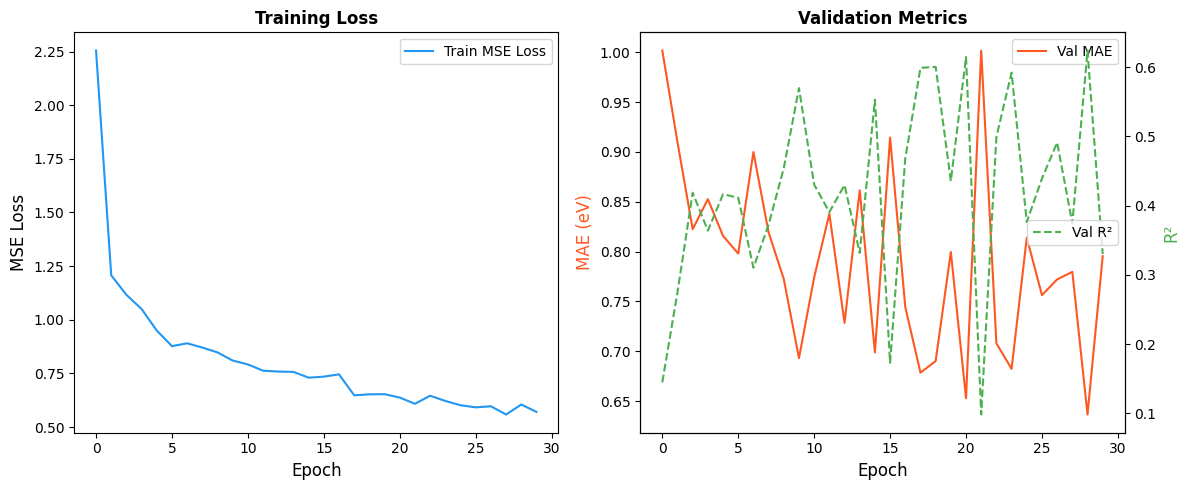

Saved fig13_training_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_losses, color="#2196F3", linewidth=1.5, label="Train MSE Loss")
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("MSE Loss", fontsize=12)
axes[0].set_title("Training Loss", fontsize=12, fontweight="bold")
axes[0].legend()

axes[1].plot(val_maes, color="#FF5722", linewidth=1.5, label="Val MAE")
ax2 = axes[1].twinx()
ax2.plot(val_r2s, color="#4CAF50", linewidth=1.5, linestyle="--", label="Val R²")
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("MAE (eV)", fontsize=12, color="#FF5722")
ax2.set_ylabel("R²", fontsize=12, color="#4CAF50")
axes[1].set_title("Validation Metrics", fontsize=12, fontweight="bold")
axes[1].legend(loc="upper right")
ax2.legend(loc="center right")

plt.tight_layout()
plt.savefig("../figures/fig13_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig13_training_curves.png")

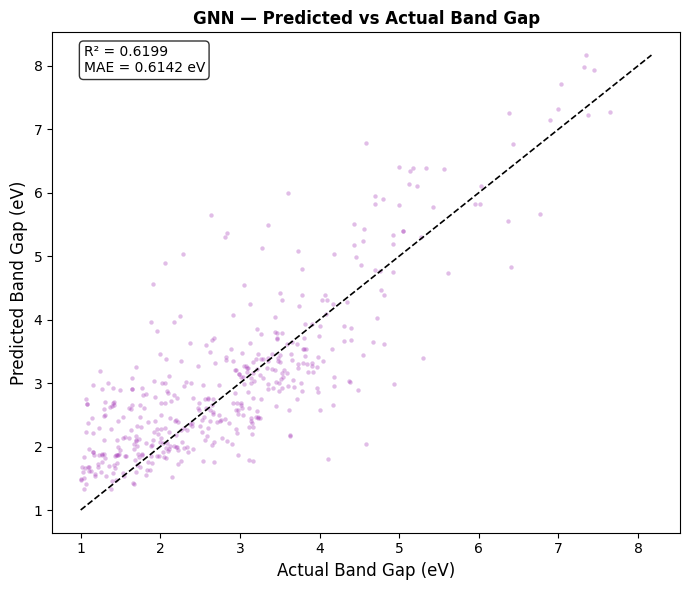

Saved fig14_gnn_predicted_vs_actual.png


In [11]:
preds = test_metrics["preds"]
targets = test_metrics["targets"]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(targets, preds, alpha=0.3, s=10, color="#9C27B0", linewidths=0)

lims = [min(targets.min(), preds.min()), max(targets.max(), preds.max())]
ax.plot(lims, lims, "k--", linewidth=1.2, label="Perfect prediction")

ax.set_xlabel("Actual Band Gap (eV)", fontsize=12)
ax.set_ylabel("Predicted Band Gap (eV)", fontsize=12)
ax.set_title("GNN — Predicted vs Actual Band Gap", fontsize=12, fontweight="bold")

ax.text(0.05, 0.92,
        f"R² = {test_metrics['r2']:.4f}\nMAE = {test_metrics['mae']:.4f} eV",
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig("../figures/fig14_gnn_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig14_gnn_predicted_vs_actual.png")

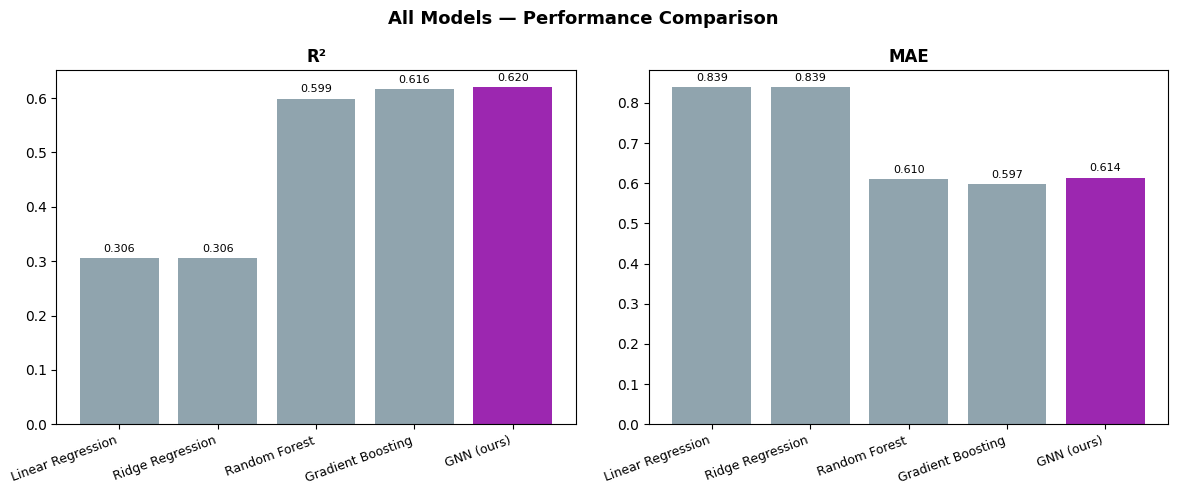

Saved fig15_full_comparison.png


In [12]:
comparison = {
    "Linear Regression": {"R²": 0.306, "MAE": 0.839},
    "Ridge Regression":  {"R²": 0.306, "MAE": 0.839},
    "Random Forest":     {"R²": 0.599, "MAE": 0.610},
    "Gradient Boosting": {"R²": 0.616, "MAE": 0.597},
    "GNN (ours)":        {"R²": test_metrics["r2"], "MAE": test_metrics["mae"]},
}

comp_df = pd.DataFrame(comparison).T
colors = ["#90A4AE"] * 4 + ["#9C27B0"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, ["R²", "MAE"]):
    bars = ax.bar(comp_df.index, comp_df[metric], color=colors)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xticklabels(comp_df.index, rotation=20, ha="right", fontsize=9)
    ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=3)

fig.suptitle("All Models — Performance Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/fig15_full_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig15_full_comparison.png")

In [13]:
results = {
    "r2": float(test_metrics["r2"]),
    "mae": float(test_metrics["mae"]),
    "rmse": float(test_metrics["mse"] ** 0.5),
    "epochs_trained": EPOCHS,
    "best_val_mae": float(best_val_mae),
    "n_train": len(train_data),
    "n_val": len(val_data),
    "n_test": len(test_data),
}

import json
with open("../data/processed/gnn_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("GNN results saved to data/processed/gnn_results.json")
print("\nPhase 4 complete.")

GNN results saved to data/processed/gnn_results.json

Phase 4 complete.
